## Writer Data Cleaning and Analysis

/var/folders/sb/jyxnm30n3_q45d56yy8qh8jm0000gn/T/ipykernel_34422/2581483996.py:6: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  basics = pd.read_csv("title.basics.tsv", sep='\t', na_values='\\N')


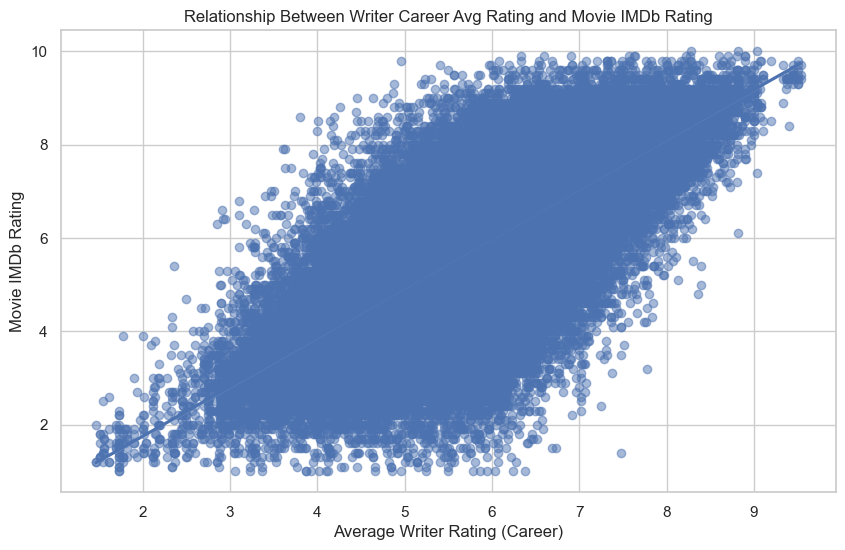

Correlation between writer career rating and movie rating: 0.706


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
basics = pd.read_csv("title.basics.tsv", sep='\t', na_values='\\N')
ratings = pd.read_csv("title.ratings.tsv", sep='\t', na_values='\\N')
crew = pd.read_csv("title.crew.tsv", sep='\t', na_values='\\N')

# Keep only movies
movies = basics[basics['titleType'] == 'movie']
movies = movies[['tconst', 'primaryTitle', 'startYear']]

# Merge ratings and crew with movies
movie_data = movies.merge(ratings, on='tconst').merge(crew, on='tconst')

# Drop rows with missing writers
movie_data = movie_data.dropna(subset=['writers'])

# Writers can be multiple; split them into individual rows
movie_data = movie_data.assign(writer_ids=movie_data['writers'].str.split(','))
movie_data = movie_data.explode('writer_ids')

# Group by writer to compute average rating
writer_stats = movie_data.groupby('writer_ids')['averageRating'].agg(['mean', 'count']).reset_index()
writer_stats.columns = ['writer_id', 'avg_rating', 'movie_count']

# Filter to writers with at least 3 movies for more reliable stats
writer_stats = writer_stats[writer_stats['movie_count'] >= 3]

# Merge writer stats back to original movie data
movie_with_writer_info = movie_data.merge(writer_stats, left_on='writer_ids', right_on='writer_id')

# Average writer rating per movie (in case of multiple writers)
writer_impact_per_movie = movie_with_writer_info.groupby('tconst').agg({
    'averageRating': 'first',  # actual IMDb rating
    'avg_rating': 'mean',      # average writer's average score
    'primaryTitle': 'first',
    'startYear': 'first'
}).reset_index()

# Plot: How well writer reputation predicts movie rating
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.regplot(x='avg_rating', y='averageRating', data=writer_impact_per_movie, scatter_kws={'alpha':0.5})
plt.xlabel('Average Writer Rating (Career)')
plt.ylabel('Movie IMDb Rating')
plt.title('Relationship Between Writer Career Avg Rating and Movie IMDb Rating')
plt.show()

# Correlation
correlation = writer_impact_per_movie['avg_rating'].corr(writer_impact_per_movie['averageRating'])
print(f"Correlation between writer career rating and movie rating: {correlation:.3f}")